# Phases 3–6: dry-run, probe, bulk load, verification

Follow-along driver for `update_nationality.py` — the script stays the single source
of truth; this notebook imports its functions and walks the run step by step.

Sections 1–3 are local-only. Section 4 authenticates and runs **read-only** SOQL.
Sections 5 (probe: ONE record) and 6 (bulk load, 1 job of ~2,669) **write to
production** and are each gated behind an explicit flag you have to flip by hand.
Section 8 archives the batch to history after a verified load.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # repo root
sys.path.insert(0, str(Path.cwd()))         # this folder: update_nationality

import pandas as pd

import update_nationality as un
from config import load_mysql_config
from mysql_client import MySQLClient

BATCH_ID = "2026-08-25_nationality_backfill"

# Phase 2 contract: staging frozen 2026-08-25, 2,669 rows (codes AT 1,973 /
# DE 664 / CH 29 / CZ 2 / AE 1). Dry-run verified: one signature group,
# header Id,NationalityCountryCode__pc, no empty cells.
EXPECTED_ROWS = 2669

db = MySQLClient(load_mysql_config())
print("connected | batch:", BATCH_ID)

## 1. Load the staged batch (local, read-only)

Same row selection the script uses: update rows, not excluded, nationality present,
not yet processed. After a successful load the open count drops to 0 — flip
`AFTER_LOAD = True` for post-load reruns.

In [ ]:
AFTER_LOAD = False  # True once the bulk load ran: open rows are then expected to be 0

rows = db.fetch_all("""
    SELECT row_id, sf_account_id, email,
           nationality_country_code
    FROM crm_imp_person_accounts
    WHERE _batch_id = %s AND _operation = 'update' AND _excluded = 0
      AND _nationality_processed_at IS NULL
      AND sf_account_id IS NOT NULL
      AND nationality_country_code IS NOT NULL AND nationality_country_code <> ''
""", (BATCH_ID,))
print(f"{len(rows):,} rows open")

if not AFTER_LOAD and EXPECTED_ROWS is not None:
    assert len(rows) == EXPECTED_ROWS, "open rows differ from the phase 2 contract"
    print("matches the phase 2 contract")

## 2. Build the payload and eyeball it (local)

`row_to_sf_record` is the exact mapper the load uses: only `Id` plus
`NationalityCountryCode__pc`, and the field is **omitted entirely** when the source is
empty (never happens here — staging asserts every row has a code). One field means one
signature group, i.e. a single Bulk job.

In [ ]:
records = [un.row_to_sf_record(r) for r in rows]
groups = un.group_by_signature(records)
print("signature groups (fields -> records):")
for sig, recs in sorted(groups.items(), key=lambda kv: -len(kv[1])):
    print(f"  {list(sig)}: {len(recs):,}")

preview = pd.DataFrame(records[:5])
preview

## 3. Phase 3 — dry-run (local, no Salesforce contact)

Runs the script itself with `--dry-run`: builds one CSV per signature group under
`<repo-root>/local_data/dry_run_nationality_backfill_*.csv`. Open it and check:
header = `Id,NationalityCountryCode__pc`, no empty cells anywhere, every code ISO-2
from the recon set (AT, DE, CH, CZ, SK, AE, ...).

In [ ]:
import subprocess

proc = subprocess.run(
    [sys.executable, str(Path.cwd() / "update_nationality.py"), BATCH_ID, "--dry-run"],
    cwd=str(Path.cwd().parent), capture_output=True, text=True,
)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"dry-run exited {proc.returncode}")

## 4. Authenticate + live spot-check (prod, READ-ONLY)

Samples 500 staged accounts and runs the same live check the loader runs on everything:
how many already have a `NationalityCountryCode__pc` in prod (filled since the mirror
refresh)? A handful is normal drift; a large share means the mirror is stale —
re-refresh and re-stage.

In [ ]:
from salesforce_client_prod import SalesforceClientCC, load_salesforce_cc_config_from_env

sf = SalesforceClientCC(load_salesforce_cc_config_from_env())
sf.authenticate()
print("authenticated")

sample_ids = [str(r["sf_account_id"]) for r in rows[:500]]
taken = un.accounts_with_nationality(sf, sample_ids)
print(f"live check on {len(sample_ids)} sampled accounts: {len(taken)} already have NationalityCountryCode__pc")

## 5. Phase 4 — probe record (prod, WRITES ONE ACCOUNT)

Put the agreed test account's 18-char Id into `PROBE_ACCOUNT_ID` (it must be in the
open batch), then flip `RUN_PROBE = True`. Uses a single REST PATCH — same field
payload as the bulk load. The readback afterwards shows the nationality AND the other
profile fields, to prove nothing else changed. Eyeball it in the UI too, then business
sign-off **before** section 6.

In [ ]:
RUN_PROBE = False          # <- flip by hand for the one probe update
PROBE_ACCOUNT_ID = ""      # <- the agreed test account's 18-char Id, from the open batch

if RUN_PROBE:
    candidates = [r for r in rows if str(r["sf_account_id"]) == PROBE_ACCOUNT_ID]
    assert candidates, f"account {PROBE_ACCOUNT_ID!r} is not in the open batch"
    probe_row = candidates[0]
    payload = {k: v for k, v in un.row_to_sf_record(probe_row).items() if k != "Id"}
    print("payload:", payload)
    sf.update_account_by_id(PROBE_ACCOUNT_ID, payload)
    print("probe account updated:", PROBE_ACCOUNT_ID)
else:
    print("probe skipped (RUN_PROBE = False)")

In [ ]:
if RUN_PROBE:
    rec = sf.query_all(
        f"SELECT Id, PersonEmail, NationalityCountryCode__pc, FirstName, LastName, "
        f"PersonBirthdate, PreferredLanguage__pc, InvestCustomer__pc, "
        f"InvestmentStatus__pc, LastModifiedDate FROM Account WHERE Id = '{PROBE_ACCOUNT_ID}'"
    )["records"]
    for x in rec:
        x.pop("attributes", None)
    print("— account as Salesforce stored it —")
    display(pd.DataFrame(rec).T)
    print("check: NationalityCountryCode__pc is the staged ISO-2 code,")
    print("       everything else unchanged")

## 6. Phase 5 — bulk load (prod, WRITES ~2,669 ACCOUNTS)

Runs the script itself, so the real run is exactly what was dry-run — plus the full
live skip-check (accounts whose `NationalityCountryCode__pc` got filled since the
mirror are skipped, logged, and marked `_excluded` in staging), the duplicate-Id abort,
per-job re-authentication, an abort after 3 consecutive job errors, and the per-job
`_nationality_processed_at` writeback. A crashed run is resumable by re-running the
same command. The script exits non-zero on ANY record failure or job error.
Expect 1 job, a few minutes; monitor in Setup -> Bulk Data Load Jobs.

**Does not run without Arsal's explicit go-ahead.** Flip `RUN_LOAD = True` only then.
The probe account is already updated, so the live skip-check will exclude it — that
one skip is expected.

In [ ]:
import subprocess

RUN_LOAD = False  # <- Arsal's explicit go-ahead required (phase 5 gate)

if RUN_LOAD:
    assert EXPECTED_ROWS is not None, (
        "fill EXPECTED_ROWS in the setup cell with the frozen count from 03 "
        "before loading - the contract check must not be skipped for the real run"
    )
    proc = subprocess.run(
        [sys.executable, str(Path.cwd() / "update_nationality.py"), BATCH_ID],
        cwd=str(Path.cwd().parent), capture_output=True, text=True,
    )
    print(proc.stdout[-8000:])
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(f"load exited {proc.returncode} - fix before re-running")
else:
    print("bulk load skipped (RUN_LOAD = False)")

## 7. Phase 6 — verification (prod, read-only)

Live SOQL: how many invest customers still have no nationality? Started at 2,761;
after the load expect ~92 (the unmatched review list) plus whatever the live
skip-check left out. Plus staging writeback completeness: `still_open` (open AND not
excluded) must be 0; `excluded` holds the live-skips including the probe account.

In [ ]:
remaining = sf.query_all(
    "SELECT COUNT(Id) n FROM Account "
    "WHERE IsPersonAccount = true "
    "AND InvestCustomer__pc = true AND NationalityCountryCode__pc = null"
)["records"][0]["n"]
print(f"live invest customers still without nationality: {remaining:,}")

open_rows = db.fetch_df("""
    SELECT SUM(_nationality_processed_at IS NULL AND _excluded = 0) AS still_open,
           SUM(_excluded = 1) AS excluded,
           SUM(_nationality_processed_at IS NOT NULL) AS processed,
           COUNT(*) AS total
    FROM crm_imp_person_accounts
    WHERE _batch_id = %s
""", (BATCH_ID,))
print(open_rows.to_string(index=False))
print("\nmismatch? check <repo-root>/local_data/skipped_* and failed_* before touching anything")

## 8. Archive the batch (local MySQL, after verified load only)

Snapshots the batch into `crm_imp_person_accounts_history` (which has a
`nationality_country_code` column) and deletes it from the staging table.
Only run once section 7 is clean: `still_open = 0` and the live count matches.

In [ ]:
RUN_ARCHIVE = False  # <- flip by hand after section 7 is verified clean

if RUN_ARCHIVE:
    # Raw connector instead of MySQLClient: the proc returns a result set,
    # which db.execute never consumes ("Unread result found"). The proc
    # commits internally; the outer connection only needs to read everything.
    import mysql.connector
    cfg = load_mysql_config()
    conn = mysql.connector.connect(host=cfg.host, user=cfg.user, password=cfg.password,
                                   database=cfg.database, port=cfg.port)
    cur = conn.cursor(dictionary=True)
    cur.execute("CALL sp_archive_crm_imp_person_accounts(%s, %s)",
                (BATCH_ID, "update_nationality.py"))
    while True:
        if cur.with_rows:
            for r in cur.fetchall():
                print(r)
        if not cur.nextset():
            break
    cur.close()
    conn.close()

    archived = db.fetch_one(
        "SELECT COUNT(*) AS n FROM crm_imp_person_accounts_history WHERE _batch_id = %s",
        (BATCH_ID,),
    )["n"]
    left = db.fetch_one(
        "SELECT COUNT(*) AS n FROM crm_imp_person_accounts WHERE _batch_id = %s",
        (BATCH_ID,),
    )["n"]
    print(f"archived {archived:,} rows to history, {left} left in staging")
else:
    print("archive skipped (RUN_ARCHIVE = False)")

## 9. Segmentation coverage: nationality + preferred language (prod, read-only)

Both fields feed invest segmentation. Live SOQL across ALL invest-flagged person
accounts: coverage (filled vs empty) and the value breakdown for
`NationalityCountryCode__pc` and `PreferredLanguage__pc`. Run any time — after the
load the nationality gap should be just the ~92 unmatched-review accounts.

In [18]:
BASE = "FROM Account WHERE IsPersonAccount = true AND InvestCustomer__pc = true"

total = sf.query_all(f"SELECT COUNT(Id) n {BASE}")["records"][0]["n"]

def breakdown(field):
    recs = sf.query_all(
        f"SELECT {field} v, COUNT(Id) n {BASE} GROUP BY {field} ORDER BY COUNT(Id) DESC"
    )["records"]
    df = pd.DataFrame([{"value": r["v"], "n": r["n"]} for r in recs])
    df["pct"] = (df["n"] / total * 100).round(1)
    filled = int(df.loc[df["value"].notna(), "n"].sum())
    print(f"\n{field}: {filled:,}/{total:,} filled ({filled/total*100:.1f}% coverage)")
    return df

print(f"invest-flagged person accounts: {total:,}")
nat = breakdown("NationalityCountryCode__pc")
display(nat)
lang = breakdown("PreferredLanguage__pc")
display(lang)
# PersonMailingCountry is the standard field (no *CountryCode variant on this org).
# Low coverage here is expected until the billing->mailing backfill runs;
# BillingCountryCode__c (custom, ISO-2, migration-era) is where the country
# actually lives for these accounts today.
mail = breakdown("PersonMailingCountry")
display(mail)
bill = breakdown("BillingCountryCode__c")
display(bill)

invest-flagged person accounts: 6,158

NationalityCountryCode__pc: 6,066/6,158 filled (98.5% coverage)


,value,n,pct
0,AT,4509,73.2
1,DE,1455,23.6
2,NaN,92,1.5
3,CH,57,0.9
4,IT,14,0.2
5,SK,5,0.1
6,RO,3,0.0
7,SI,3,0.0
8,CZ,3,0.0
9,HU,3,0.0



PreferredLanguage__pc: 6,145/6,158 filled (99.8% coverage)


,value,n,pct
0,de,6046,98.2
1,en,93,1.5
2,NaN,13,0.2
3,it,5,0.1
4,sk,1,0.0



PersonMailingCountry: 1,233/6,158 filled (20.0% coverage)


,value,n,pct
0,NaN,4925,80.0
1,AT,958,15.6
2,DE,254,4.1
3,CH,13,0.2
4,Austria,4,0.1
5,SK,1,0.0
6,FR,1,0.0
7,HR,1,0.0
8,CZ,1,0.0



BillingCountryCode__c: 5,677/6,158 filled (92.2% coverage)


,value,n,pct
0,AT,4321,70.2
1,DE,1294,21.0
2,NaN,481,7.8
3,CH,52,0.8
4,CZ,3,0.0
5,FR,1,0.0
6,AU,1,0.0
7,HR,1,0.0
8,IT,1,0.0
9,HU,1,0.0


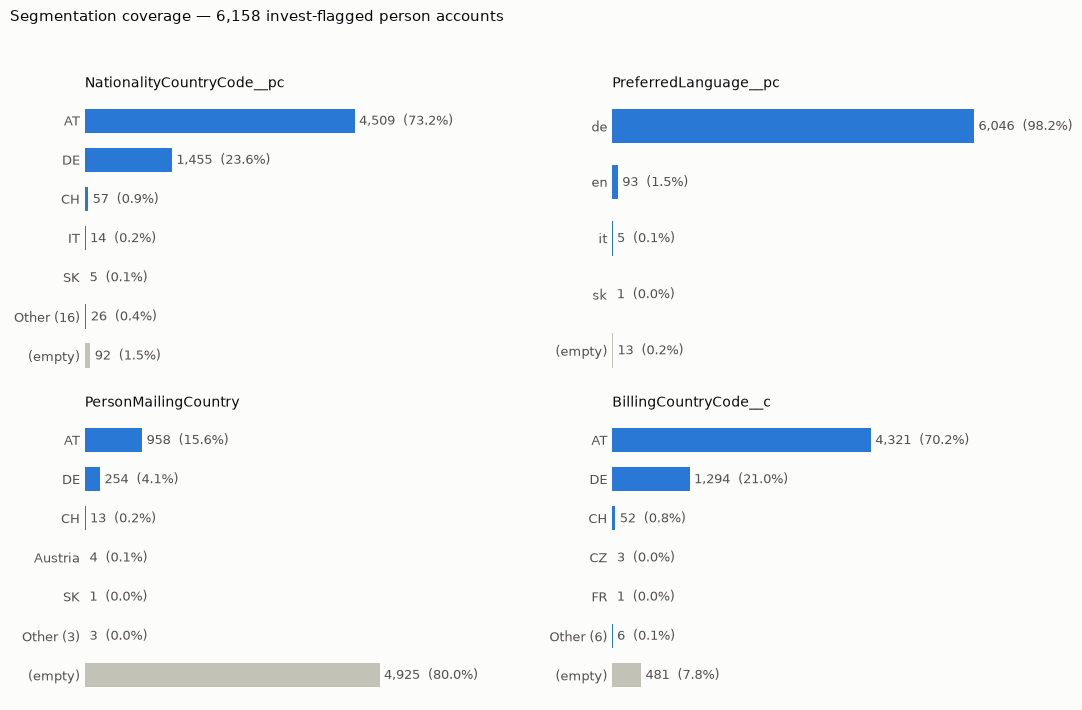

In [19]:
import matplotlib.pyplot as plt

BLUE, GRAY, INK, MUTED = "#2a78d6", "#c3c2b7", "#0b0b0b", "#52514e"

def fold(df, top=5):
    """Top-N + 'Other (k)' + '(empty)' as the last row; keeps counts honest."""
    filled = df[df["value"].notna()].reset_index(drop=True)
    rows = filled.head(top)[["value", "n"]].values.tolist()
    tail = filled.iloc[top:]
    if len(tail):
        rows.append([f"Other ({len(tail)})", int(tail["n"].sum())])
    empty = int(df.loc[df["value"].isna(), "n"].sum())
    if empty:
        rows.append(["(empty)", empty])
    return rows

panels = [("NationalityCountryCode__pc", nat),
          ("PreferredLanguage__pc", lang),
          ("PersonMailingCountry", mail),
          ("BillingCountryCode__c", bill)]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), facecolor="#fcfcfb")

for ax, (title, df) in zip(axes.flat, panels):
    rows = fold(df)
    labels = [r[0] for r in rows][::-1]
    values = [r[1] for r in rows][::-1]
    colors = [GRAY if l == "(empty)" else BLUE for l in labels]
    bars = ax.barh(labels, values, color=colors, height=0.62)
    for bar, v in zip(bars, values):
        ax.text(bar.get_width() + total * 0.012, bar.get_y() + bar.get_height() / 2,
                f"{v:,}  ({v / total * 100:.1f}%)", va="center", fontsize=9, color=MUTED)
    ax.set_title(title, fontsize=10, color=INK, loc="left")
    ax.set_xlim(0, total * 1.22)  # headroom for the labels
    ax.tick_params(labelsize=9, colors=MUTED, length=0)
    ax.xaxis.set_visible(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_facecolor("#fcfcfb")

fig.suptitle(f"Segmentation coverage — {total:,} invest-flagged person accounts",
             fontsize=11, color=INK, x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()